In [361]:
# install dependencies (run for the first time only)
# !pip install pandas numpy matplotlib seaborn scikit-learn statsmodels

### **`Data cleaning`**

In [362]:
# import dependencies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler

In [363]:
# load data
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 6)
plt.rcParams['font.size'] = 12

url = r'https://raw.githubusercontent.com/dhieu0901/DSEB65A_MachineLearningProject_Group5/refs/heads/main/data/Hanoi%20Daily%2010%20years.csv'

df = pd.read_csv(url)

print("Data size (Rows, Columns):", df.shape)
print(df.head())

Data size (Rows, Columns): (3660, 33)
    name   datetime  tempmax  tempmin  temp  feelslikemax  feelslikemin  \
0  Hanoi  9/20/2015     33.0     26.7  29.3          41.7          30.5   
1  Hanoi  9/21/2015     29.5     25.0  26.8          34.4          25.0   
2  Hanoi  9/22/2015     28.5     25.0  25.9          32.8          25.0   
3  Hanoi  9/23/2015     31.3     25.5  28.0          39.7          25.5   
4  Hanoi  9/24/2015     34.5     26.5  29.9          43.5          26.5   

   feelslike   dew  humidity  ...  solarenergy  uvindex  severerisk  \
0       35.4  25.7      81.5  ...         12.2        5         NaN   
1       29.2  24.3      86.3  ...          5.8        3         NaN   
2       26.5  24.2      90.5  ...          7.2        3         NaN   
3       32.0  25.4      86.2  ...         12.1        5         NaN   
4       36.4  25.9      80.4  ...         19.5        8         NaN   

               sunrise               sunset  moonphase  \
0  2015-09-20T05:44:39  20

In [364]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3660 entries, 0 to 3659
Data columns (total 33 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              3660 non-null   object 
 1   datetime          3660 non-null   object 
 2   tempmax           3660 non-null   float64
 3   tempmin           3660 non-null   float64
 4   temp              3660 non-null   float64
 5   feelslikemax      3660 non-null   float64
 6   feelslikemin      3660 non-null   float64
 7   feelslike         3660 non-null   float64
 8   dew               3660 non-null   float64
 9   humidity          3660 non-null   float64
 10  precip            3660 non-null   float64
 11  precipprob        3660 non-null   int64  
 12  precipcover       3660 non-null   float64
 13  preciptype        2673 non-null   object 
 14  snow              3660 non-null   int64  
 15  snowdepth         3660 non-null   int64  
 16  windgust          3660 non-null   float64


In [365]:
df.describe()

,tempmax,tempmin,temp,feelslikemax,feelslikemin,feelslike,dew,humidity,precip,precipprob,...,windspeed,winddir,sealevelpressure,cloudcover,visibility,solarradiation,solarenergy,uvindex,severerisk,moonphase
count,3660.000000,3660.000000,3660.000000,3660.000000,3660.000000,3660.000000,3660.000000,3660.000000,3660.000000,3660.000000,...,3660.000000,3660.000000,3660.000000,3660.00000,3660.000000,3660.000000,3660.000000,3660.000000,1000.0000,3660.000000
mean,28.460519,21.882814,24.844426,32.541011,22.636202,27.320355,20.432158,78.259235,5.231195,71.912568,...,17.284863,126.427678,1011.188934,64.42776,8.616721,154.137568,13.304672,5.816940,29.2560,0.484781
std,5.810885,4.857733,5.111883,9.518917,6.047288,7.712572,5.841853,10.907329,16.031570,44.948764,...,4.953989,97.777963,7.142358,23.11523,1.738703,76.573769,6.618988,2.463028,24.4205,0.288801
min,8.000000,5.900000,7.000000,8.000000,2.100000,4.600000,-2.000000,31.000000,0.000000,0.000000,...,6.500000,0.000000,991.100000,0.00000,2.600000,0.000000,0.000000,0.000000,5.0000,0.000000
25%,24.100000,18.000000,21.000000,24.100000,18.000000,21.000000,16.700000,72.100000,0.000000,0.000000,...,13.900000,60.375000,1005.300000,50.67500,7.700000,90.875000,7.800000,4.000000,10.0000,0.250000
50%,29.400000,23.000000,26.000000,32.700000,23.000000,26.900000,22.400000,79.900000,0.217500,100.000000,...,16.600000,108.950000,1010.950000,67.50000,9.000000,152.750000,13.200000,6.000000,10.0000,0.500000
75%,33.000000,26.000000,28.900000,41.100000,26.000000,33.800000,25.200000,85.900000,2.500000,100.000000,...,20.500000,131.800000,1016.700000,82.10000,9.800000,214.925000,18.600000,8.000000,60.0000,0.750000
max,41.900000,31.000000,35.500000,52.500000,40.400000,46.200000,28.500000,100.000000,333.117000,100.000000,...,53.600000,359.800000,1037.200000,100.00000,12.600000,323.500000,27.900000,10.000000,100.0000,0.980000


In [366]:
df[:5]

,name,datetime,tempmax,tempmin,temp,feelslikemax,feelslikemin,feelslike,dew,humidity,...,solarenergy,uvindex,severerisk,sunrise,sunset,moonphase,conditions,description,icon,stations
0,Hanoi,9/20/2015,33.0,26.7,29.3,41.7,30.5,35.4,25.7,81.5,...,12.2,5,NaN,2015-09-20T05:44:39,2015-09-20T17:55:33,0.23,"Rain, Partially cloudy",Partly cloudy throughout the day with late aft...,rain,"48820099999,48823099999,48825099999,4883109999..."
1,Hanoi,9/21/2015,29.5,25.0,26.8,34.4,25.0,29.2,24.3,86.3,...,5.8,3,NaN,2015-09-21T05:44:54,2015-09-21T17:54:36,0.25,"Rain, Overcast",Cloudy skies throughout the day with a chance ...,rain,"48820099999,48823099999,48825099999,4883109999..."
2,Hanoi,9/22/2015,28.5,25.0,25.9,32.8,25.0,26.5,24.2,90.5,...,7.2,3,NaN,2015-09-22T05:45:08,2015-09-22T17:53:39,0.30,"Rain, Overcast",Cloudy skies throughout the day with a chance ...,rain,"48820099999,48823099999,48825099999,4883109999..."
3,Hanoi,9/23/2015,31.3,25.5,28.0,39.7,25.5,32.0,25.4,86.2,...,12.1,5,NaN,2015-09-23T05:45:23,2015-09-23T17:52:42,0.33,"Rain, Partially cloudy",Partly cloudy throughout the day with a chance...,rain,"48820099999,48823099999,48825099999,4883109999..."
4,Hanoi,9/24/2015,34.5,26.5,29.9,43.5,26.5,36.4,25.9,80.4,...,19.5,8,NaN,2015-09-24T05:45:38,2015-09-24T17:51:45,0.37,"Rain, Partially cloudy",Partly cloudy throughout the day with afternoo...,rain,"48820099999,48823099999,48825099999,4883109999..."


### **`Handling missing values for time-series problem`**

In [367]:
# initial data shape
# please check this carefully as we would modify it later
df.shape

(3660, 33)

In [ ]:
# handling missing values

def check_missing_values(df):
    """Return missing percentage for each column."""
    missing = df.isnull().mean() * 100
    return missing[missing > 0].sort_values(ascending=False)

missing_ratio = check_missing_values(df)
print("\nMissing Value Ratio (%):")
print(missing_ratio)

# focus on specific columns
if 'severerisk' in df.columns:
    print(f"\nsevererisk missing: {missing_ratio['severerisk']:.2f}%")
if 'preciptype' in df.columns:
    print(f"preciptype missing: {missing_ratio['preciptype']:.2f}%")


Missing Value Ratio (%):
severerisk    72.677596
preciptype    26.967213
dtype: float64

severerisk missing: 72.68%
preciptype missing: 26.97%


### **`Dropping redundant and zero-variance cols`**

In [369]:
# Constant and Zero-Variance Columns

def find_constant_columns(df):
    """Find columns with only one unique (non-null) value."""
    # This also finds numeric columns with zero variance
    return [col for col in df.columns if df[col].nunique(dropna=True) <= 1]

# find all constant columns
constant_cols = find_constant_columns(df)
print("\nConstant or Zero-Variance Columns Detected:")
print(constant_cols)

# (domain knowledge) other potential cols that should be dropped for future refactor
other_cols_to_drop = ['address', 'resolvedAddress', 'source', 'latitude', 'longitude', 'severerisk', 'stations']

# combine the lists and remove duplicates -> use set
all_cols_to_drop = list(set(constant_cols + other_cols_to_drop))

print("\nFull list of columns to be dropped:")
print(all_cols_to_drop)

# 4. drop the columns that actually exist in the dataframe
# PLEASE note that from now on we only process with cleaned_df for better later debugging
cleaned_df = df.drop(columns=[c for c in all_cols_to_drop if c in df.columns], errors='ignore')


Constant or Zero-Variance Columns Detected:
['name', 'preciptype', 'snow', 'snowdepth']

Full list of columns to be dropped:
['name', 'address', 'source', 'snow', 'longitude', 'stations', 'resolvedAddress', 'snowdepth', 'preciptype', 'severerisk', 'latitude']


In [370]:
# check the date shape
print("\nDataset shape after dropping redundant columns:")
print("Before:", df.shape, "-> After:", cleaned_df.shape)


Dataset shape after dropping redundant columns:
Before: (3660, 33) -> After: (3660, 27)


In [371]:
# call check_missing_values() again for validation
remaining_missing = check_missing_values(cleaned_df)
if(remaining_missing.empty):
    print("\nNo more missing values")
else:
    print("\nRemaining Missing Value Ratio (%):")
    print(remaining_missing)


No more missing values


### **`Correcting Data Types`**

##### **Converting to timestamp datatype for time-series analysis**

In [372]:
# convert to timestamp data type
cleaned_df['datetime'] = pd.to_datetime(cleaned_df['datetime'])
cleaned_df['sunrise'] = pd.to_datetime(cleaned_df['sunrise'])
cleaned_df['sunset'] = pd.to_datetime(cleaned_df['sunset'])

##### **Multi-label Columns processing**  

**Cols**: `conditions`, `description`.

##### **Problem**:
|   | conditions           |
|---|----------------------|
| 0 | Rain, Partially cloudy |
| 1 | Rain, Overcast        |
| 2 | Rain, Overcast        |
| 3 | Rain, Partially cloudy |
| 4 | Rain, Partially cloudy |

```python
df['description'][0], df['conditions'][0]
>> ('Partly cloudy throughout the day with late afternoon rain.', 'Rain, Partially cloudy')
```

- `df['conditions']` does not contain a single category, but rather a string with multiple values separated by commas.

- For example: `'Rain, Partially cloudy'` means the day had both `Rain` **AND** `Partially cloudy` weather conditions.

- Additionally, the `description` column provides a textual summary of conditions column. For example, the description `'Partly cloudy throughout the day with late afternoon rain.'` corresponds to the conditions `'Rain, Partially cloudy'`.

##### **Solution:**

1. Use **Multi-Label Binarization**. This technique converts each individual label within a multi-label string into a separate binary column, enabling the model to interpret each label independently rather than as a combined entity. In pandas, the simplest and most effective approach is to use the `str.get_dummies()` method.
2. Drop `df['description']`.


In [373]:
df['description'][0], df['conditions'][0]

('Partly cloudy throughout the day with late afternoon rain.',
 'Rain, Partially cloudy')

In [374]:
# multi-label cols processing
# split 'condition' col into binary cols (sep=',')
conditions_dummies = cleaned_df['conditions'].str.get_dummies(sep=', ')

# concat to the processing dataframe
cleaned_df = pd.concat([cleaned_df, conditions_dummies], axis=1)

# now the original
cleaned_df.drop('conditions', axis=1, inplace=True)

# we can and must also drop df['description'],
# because it is just the more complicated version of df['condition'] which we have already handled
cleaned_df.drop('description', axis=1, inplace=True)

##### **One-hot Encoding**

The `icon` column is of object type and needs to be transformed into a numeric format for machine learning models. To do this, we apply **One-Hot Encoding**, a technique that converts categorical data into binary vectors.

This transformation ensures the model can process the data numerically and treat each icon category as a separate feature.


In [375]:
# apply one-hot encoding
icon_dummies = pd.get_dummies(cleaned_df['icon'], prefix='icon')

# concat
cleaned_df = pd.concat([cleaned_df, icon_dummies], axis=1)

# drop orignal one
cleaned_df.drop('icon', axis=1, inplace=True)

#### **`Main: Feature Engineering`**

##### **General Philosophy**
Our goal is to create new columns (features) that answer questions the model might "ask" in order to predict the temperature. For example:

*"Was it hot or cold yesterday?"* -> **Lag Features**

*"Did the temperature trend upward last week?"* -> **Rolling Features**

*"What season is it now?"* -> **Time-based Features**

*"Is the perceived temperature much different from the actual temperature?"* -> **Interaction Features**


In [376]:
# Các thành phần thời gian cơ bản
cleaned_df['month'] = cleaned_df['datetime'].dt.month
cleaned_df['day_of_year'] = cleaned_df['datetime'].dt.dayofyear
cleaned_df['day_of_week'] = cleaned_df['datetime'].dt.dayofweek
cleaned_df['week_of_year'] = cleaned_df['datetime'].dt.isocalendar().week.astype(int)
cleaned_df['year'] = cleaned_df['datetime'].dt.year

# daylight duration
cleaned_df['daylight_duration_sec'] = (cleaned_df['sunset'] - cleaned_df['sunrise']).dt.total_seconds()

# Feature mùa và mã hóa one-hot
season_map = {1: 'Winter', 2: 'Winter', 3: 'Spring', 4: 'Spring', 5: 'Spring',
              6: 'Summer', 7: 'Summer', 8: 'Summer', 9: 'Fall', 10: 'Fall',
              11: 'Fall', 12: 'Winter'}
cleaned_df['season'] = cleaned_df['month'].map(season_map)
season_dummies = pd.get_dummies(cleaned_df['season'], prefix='season')
cleaned_df = pd.concat([cleaned_df, season_dummies], axis=1)

# Mã hóa cyclical cho các biến thời gian
cleaned_df['month_sin'] = np.sin(2 * np.pi * cleaned_df['month'] / 12)
cleaned_df['month_cos'] = np.cos(2 * np.pi * cleaned_df['month'] / 12)
cleaned_df['day_of_year_sin'] = np.sin(2 * np.pi * cleaned_df['day_of_year'] / 365.25)
cleaned_df['day_of_year_cos'] = np.cos(2 * np.pi * cleaned_df['day_of_year'] / 365.25)


In [377]:
# Mã hóa hướng gió (0-360 độ)
cleaned_df['winddir_sin'] = np.sin(np.deg2rad(cleaned_df['winddir']))
cleaned_df['winddir_cos'] = np.cos(np.deg2rad(cleaned_df['winddir']))

# Mã hóa pha mặt trăng (0-1)
cleaned_df['moonphase_sin'] = np.sin(2 * np.pi * cleaned_df['moonphase'])
cleaned_df['moonphase_cos'] = np.cos(2 * np.pi * cleaned_df['moonphase'])


In [378]:
# lag features
lag_cols = ['temp', 'humidity', 'windspeed', 'cloudcover', 'precip']
for col in lag_cols:
    # Tạo lag 1, 2, 7 ngày
    for lag in [1, 2, 7]:
        cleaned_df[f'{col}_lag_{lag}'] = cleaned_df[col].shift(lag)
    # Tạo feature chênh lệch so với ngày hôm qua
    cleaned_df[f'{col}_diff_1'] = cleaned_df[col].diff(periods=1)

# rolling: calculate on the lagged cols
for window in [3, 7, 14]:
    cleaned_df[f'temp_roll_mean_{window}'] = cleaned_df['temp'].shift(1).rolling(window=window).mean()
    cleaned_df[f'temp_roll_std_{window}'] = cleaned_df['temp'].shift(1).rolling(window=window).std()
    cleaned_df[f'humidity_roll_mean_{window}'] = cleaned_df['humidity'].shift(1).rolling(window=window).mean()



In [379]:
# Biên độ nhiệt trong ngày
cleaned_df['temp_range'] = cleaned_df['tempmax'] - cleaned_df['tempmin']

# Độ bão hòa hơi nước
cleaned_df['dew_point_depression'] = cleaned_df['temp'] - cleaned_df['dew']

# Vector gió (sử dụng các cột sin/cos đã tạo)
cleaned_df['wind_vector_ns'] = cleaned_df['windspeed'] * cleaned_df['winddir_cos']
cleaned_df['wind_vector_ew'] = cleaned_df['windspeed'] * cleaned_df['winddir_sin']

# Bức xạ mặt trời hiệu dụng
cleaned_df['effective_radiation'] = cleaned_df['solarradiation'] * (1 - cleaned_df['cloudcover'] / 100)

# Interaction
cleaned_df['humidity_temp_interact'] = cleaned_df['humidity'] * cleaned_df['temp']


In [ ]:
# Danh sách các cột gốc cần xóa vì thông tin đã được chuyển hóa
cols_to_drop = [
    'datetime', 'sunrise', 'sunset', # Đã khai thác
    'winddir', 'moonphase',         # Đã mã hóa
    'season',                       # Đã mã hóa one-hot
    'name', 'stations', 'description', 'preciptype', 'icon', 'conditions', # Cột không cần thiết
    'severerisk', # Có quá nhiều giá trị thiếu
    'feelslike',
    'feelslikemax',
    'feelslikemin',
]

# Chỉ xóa các cột thực sự tồn tại
existing_cols_to_drop = [col for col in cols_to_drop if col in cleaned_df.columns]
cleaned_df.drop(columns=existing_cols_to_drop, inplace=True)
print(f"   - Dropped {len(existing_cols_to_drop)} unnecessary columns.")

# Xóa tất cả các dòng có NaN (lag && rolling)
initial_rows = len(cleaned_df)
cleaned_df.dropna(inplace=True)
final_rows = len(cleaned_df)
print(f"   - Dropped {initial_rows - final_rows} rows with NaN values.")


   - Dropped 9 unnecessary columns.
   - Dropped 14 rows with NaN values.


In [381]:
cleaned_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3646 entries, 14 to 3659
Data columns (total 77 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   tempmax                 3646 non-null   float64
 1   tempmin                 3646 non-null   float64
 2   temp                    3646 non-null   float64
 3   dew                     3646 non-null   float64
 4   humidity                3646 non-null   float64
 5   precip                  3646 non-null   float64
 6   precipprob              3646 non-null   int64  
 7   precipcover             3646 non-null   float64
 8   windgust                3646 non-null   float64
 9   windspeed               3646 non-null   float64
 10  sealevelpressure        3646 non-null   float64
 11  cloudcover              3646 non-null   float64
 12  visibility              3646 non-null   float64
 13  solarradiation          3646 non-null   float64
 14  solarenergy             3646 non-null   floa

#### 76 features are...
-> Lets go do some correlation analysis

### **`Correlation analysis`**

In [ ]:
# Select numeric columns
num_df = cleaned_df.select_dtypes(include=[np.number])

# Compute Pearson correlation
corr_matrix = num_df.corr()

# Visualization function
def plot_correlation_heatmap(correlation_matrix, figsize=(20, 15), annot=False, title="Correlation Matrix"):
    """
    Vẽ heatmap tương quan. Mặc định tắt annot để dễ nhìn hơn với ma trận lớn.
    """
    mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
    plt.figure(figsize=figsize)
    sns.heatmap(correlation_matrix,
                mask=mask,          
                cmap='coolwarm',
                center=0,
                annot=annot,        # on/off
                fmt=".2f",
                linewidths=.5)
    plt.title(title, fontsize=16)
    plt.tight_layout()
    plt.show()

# # call function
# plot_correlation_heatmap(corr_matrix, annot=False, title="Tổng Quan Tương Quan Giữa Các Feature")


In [392]:
# Sort top correlations with temp
top_corr = corr_matrix['temp'].abs().sort_values(ascending=False).head(40)
print("\nTop 40 Features Correlated with 'temp':")
print(top_corr)


Top 40 Features Correlated with 'temp':
temp                      1.000000
tempmax                   0.977416
tempmin                   0.969427
temp_lag_1                0.945086
temp_roll_mean_3          0.905448
dew                       0.902942
temp_roll_mean_7          0.874657
temp_lag_2                0.874333
sealevelpressure          0.867848
temp_roll_mean_14         0.864984
humidity_temp_interact    0.856874
day_of_year_cos           0.817616
daylight_duration_sec     0.763251
temp_lag_7                0.759511
month_cos                 0.716122
solarradiation            0.615830
solarenergy               0.615616
uvindex                   0.580681
temp_roll_std_14          0.497333
month_sin                 0.463340
temp_range                0.394088
winddir_cos               0.389689
wind_vector_ns            0.384688
visibility                0.381965
temp_roll_std_7           0.375660
Partially cloudy          0.362948
effective_radiation       0.359719
Overcast      

In [393]:
# Handling multicolinearity

def find_highly_correlated_features(corr_matrix, threshold=0.95):
    """
    Find feature pairs with correlation above the specified threshold.
    """
    # Get the upper triangle of the correlation matrix
    upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

    # Find feature pairs with correlation > threshold
    highly_correlated_pairs = [
        (column, upper_tri[column].abs().idxmax(), upper_tri[column].abs().max())
        for column in upper_tri.columns if upper_tri[column].abs().max() > threshold
    ]

    # Sort for easier viewing
    sorted_pairs = sorted(highly_correlated_pairs, key=lambda x: x[2], reverse=True)

    return sorted_pairs


def drop_correlated_features(df, correlated_pairs, target_col):
    """
    Drop one feature from each highly correlated pair.
    This function keeps the feature that has higher correlation with the target variable.
    Args:
        df (pd.DataFrame): The DataFrame containing the data.
        correlated_pairs (list): List of highly correlated feature pairs from the find_highly_correlated_features function.
        target_col (str): The name of the target column (e.g., 'temp').
    Returns:
        pd.DataFrame: The new DataFrame with features dropped.
        set: A set of dropped columns.
    """
    cols_to_drop = set()

    # Calculate correlation of all features with the target column once
    corr_with_target = df.corr()[target_col].abs()

    # Iterate through the pairs found
    for feat1, feat2, _ in correlated_pairs:
        # Get the correlation values with the target for each feature in the pair
        corr1 = corr_with_target.get(feat1, 0)
        corr2 = corr_with_target.get(feat2, 0)

        # Decide which feature to drop
        if corr1 > corr2:
            # Keep feat1, drop feat2
            cols_to_drop.add(feat2)
        else:
            # Keep feat2, drop feat1
            cols_to_drop.add(feat1)

    # Drop the identified columns
    df_reduced = df.drop(columns=list(cols_to_drop))

    print(f"\nDropped {len(cols_to_drop)} features due to multicollinearity.")
    if cols_to_drop:
        print("- Dropped columns:", list(cols_to_drop))

    return df_reduced, cols_to_drop

In [385]:
# Find pairs with correlation > 0.95
correlated_pairs = find_highly_correlated_features(corr_matrix, threshold=0.95)

print("\n feature pairs with very high correlation (> 0.95):")
for feat1, feat2, corr_val in correlated_pairs:
    print(f"- {feat1:<25} and {feat2:<25} : {corr_val:.4f}")

df_final, dropped_cols = drop_correlated_features(df=cleaned_df,
                                                  correlated_pairs=correlated_pairs,
                                                  target_col='temp')


 feature pairs with very high correlation (> 0.95):
- Rain                      and precipprob                : 1.0000
- solarenergy               and solarradiation            : 0.9999
- day_of_year               and month                     : 0.9965
- dew_point_depression      and humidity                  : 0.9915
- temp_roll_mean_3          and temp_lag_2                : 0.9896
- humidity_temp_interact    and dew                       : 0.9889
- day_of_year_cos           and daylight_duration_sec     : 0.9854
- month_cos                 and daylight_duration_sec     : 0.9839
- temp                      and tempmax                   : 0.9774
- week_of_year              and day_of_year               : 0.9754
- temp_roll_mean_14         and temp_roll_mean_7          : 0.9699
- uvindex                   and solarradiation            : 0.9612
- temp_roll_mean_7          and temp_roll_mean_3          : 0.9599
- wind_vector_ns            and winddir_cos               : 0.9578
- day_of_

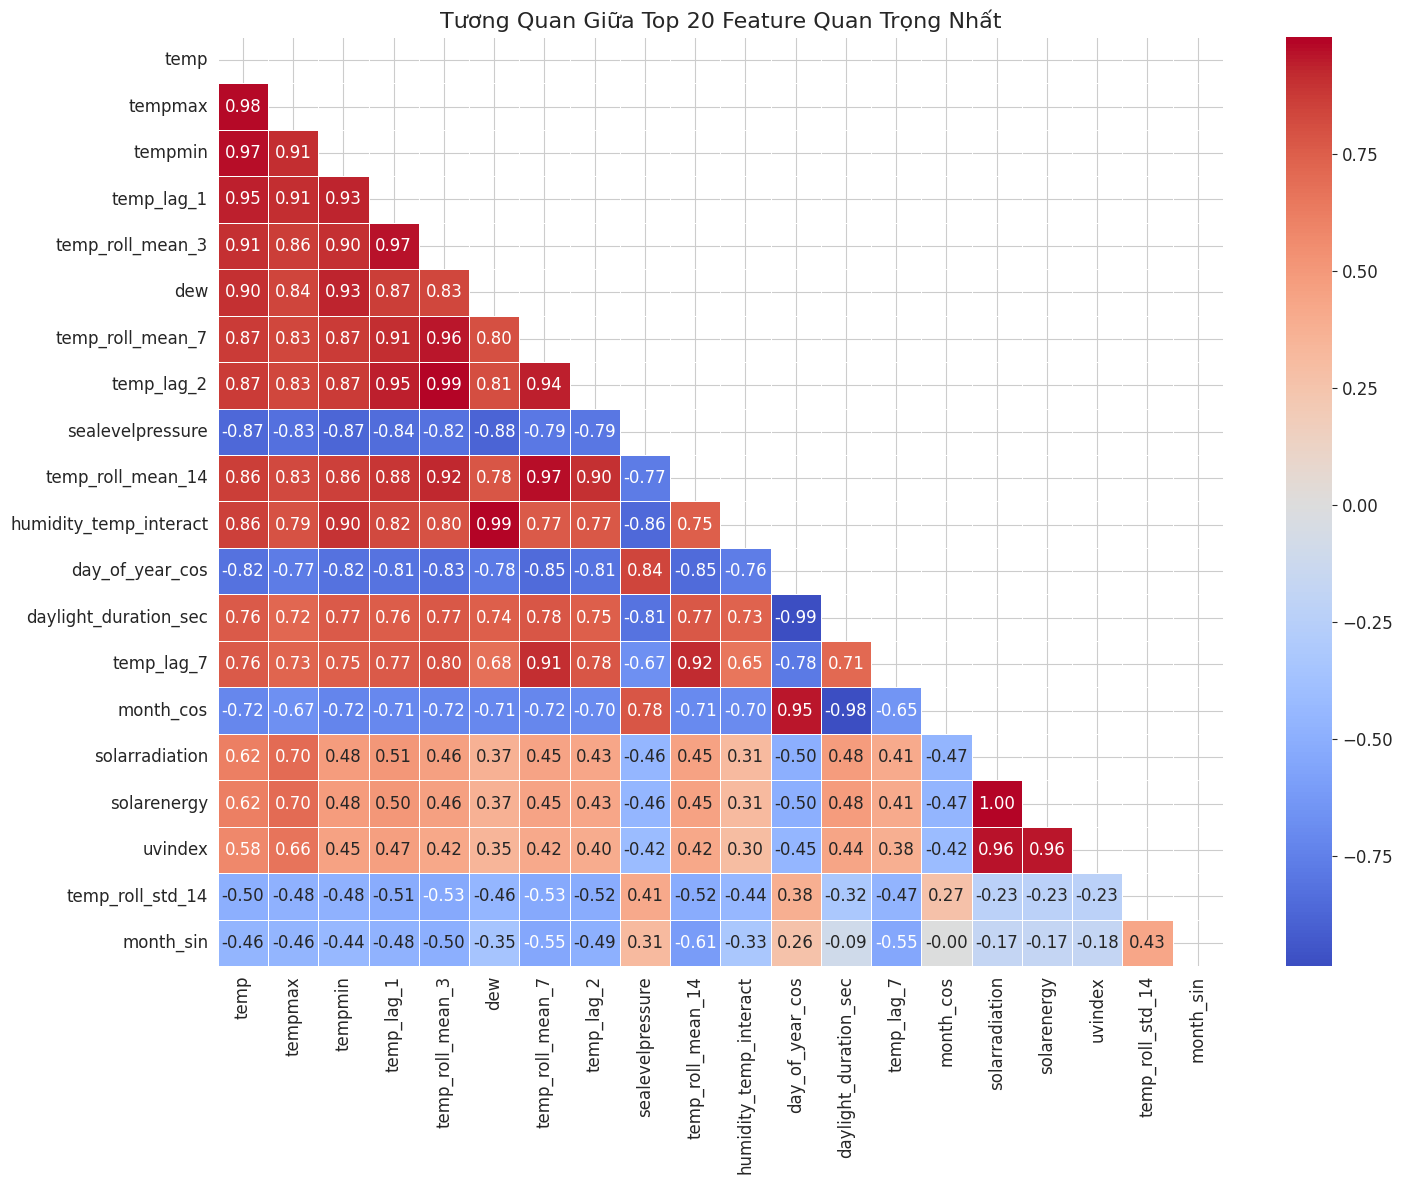

In [386]:
# Lấy top 20 features từ danh sách tương quan với target
top_20_features = top_corr.head(20).index

# Tạo ma trận tương quan mới chỉ với các feature này
small_corr_matrix = cleaned_df[top_20_features].corr()

# Bây giờ mới vẽ heatmap chi tiết
plot_correlation_heatmap(small_corr_matrix, figsize=(15,12), annot=True, title="Tương Quan Giữa Top 20 Feature Quan Trọng Nhất")

Top 20 features sau khi đã loại bỏ đa cộng tuyến:
temp                   1.000000
tempmin                0.969427
temp_lag_1             0.945086
temp_roll_mean_3       0.905448
dew                    0.902942
sealevelpressure       0.867848
day_of_year_cos        0.817616
temp_lag_7             0.759511
season_Winter          0.719408
solarradiation         0.615830
season_Summer          0.567873
temp_roll_std_14       0.497333
month_sin              0.463340
temp_range             0.394088
winddir_cos            0.389689
visibility             0.381965
temp_roll_std_7        0.375660
Partially cloudy       0.362948
effective_radiation    0.359719
Overcast               0.342813
Name: temp, dtype: float64


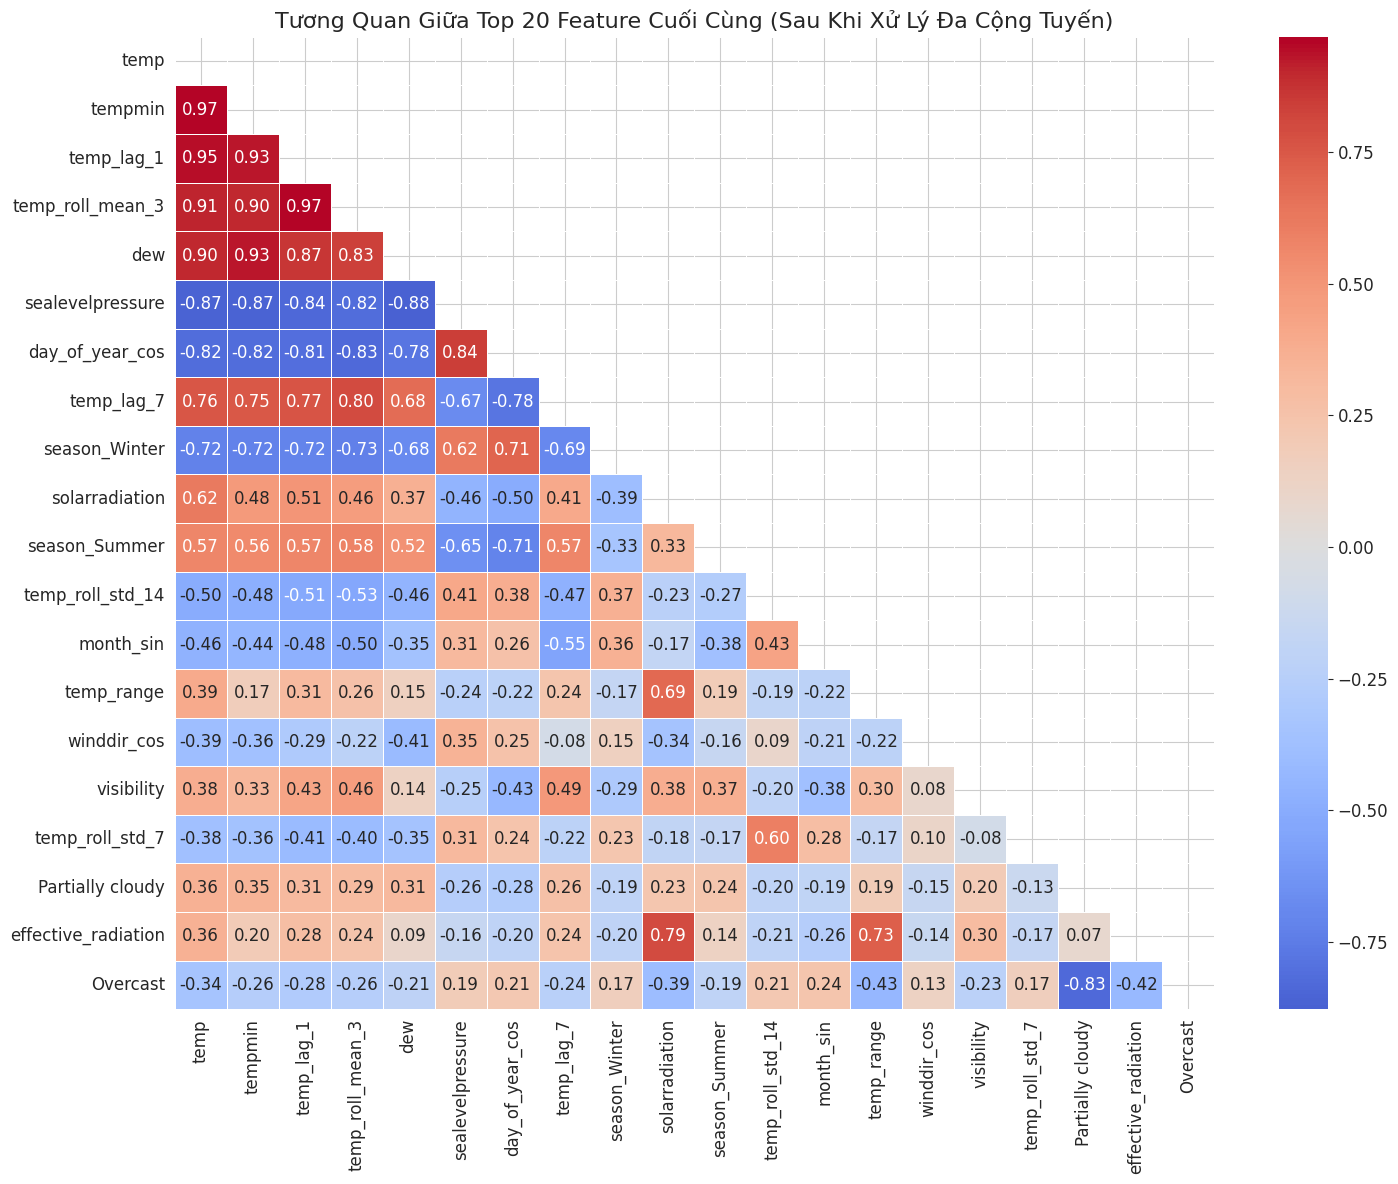

In [395]:
# 1. Tính toán lại ma trận tương quan trên df_final
corr_matrix_final = df_final.corr()

# 2. Lấy chuỗi tương quan với cột 'temp' và sắp xếp
corr_with_target_final = corr_matrix_final['temp'].abs().sort_values(ascending=False)

# 3. In ra top 20 feature mạnh nhất còn lại
print("Top 20 features sau khi đã loại bỏ đa cộng tuyến:")
print(corr_with_target_final.head(20))

# 4. Lấy danh sách tên của top 20 feature
top_20_final_features = corr_with_target_final.head(20).index

# 5. Tạo ma trận tương quan mới chỉ với các feature này
small_corr_matrix_final = df_final[top_20_final_features].corr()

# 6. Vẽ heatmap chi tiết cuối cùng
plot_correlation_heatmap(
    small_corr_matrix_final,
    figsize=(15, 12),
    annot=True,
    title="Tương Quan Giữa Top 20 Feature Cuối Cùng (Sau Khi Xử Lý Đa Cộng Tuyến)"
)

Top 30 features quan trọng nhất (tính trên tập train):
                 feature  importance
0                tempmin    0.929000
58            temp_range    0.037384
32            temp_lag_1    0.012857
2               humidity    0.008680
34           temp_diff_1    0.001466
10        solarradiation    0.001378
1                    dew    0.001184
51      temp_roll_mean_3    0.000640
60   effective_radiation    0.000506
7       sealevelpressure    0.000491
43      cloudcover_lag_1    0.000417
27       day_of_year_cos    0.000295
33            temp_lag_7    0.000267
8             cloudcover    0.000263
3                 precip    0.000263
29           winddir_cos    0.000229
9             visibility    0.000204
56      temp_roll_std_14    0.000203
38       humidity_diff_1    0.000194
45      cloudcover_lag_7    0.000183
54       temp_roll_std_7    0.000181
52       temp_roll_std_3    0.000176
37        humidity_lag_7    0.000173
5               windgust    0.000170
44      cloudcover_l

/tmp/ipython-input-2445001175.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feature_importance_df.head(20), palette='viridis')


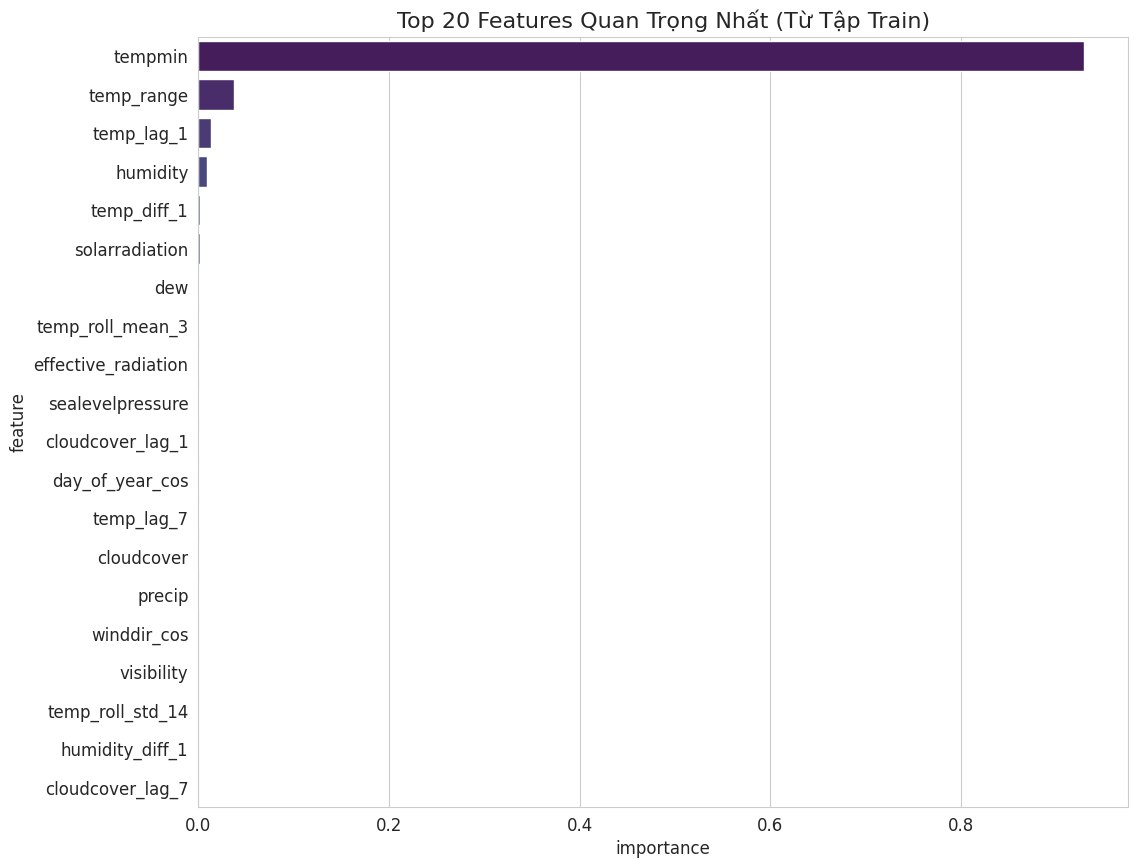


Shape mới của X_train: (2916, 30)
Shape mới của X_test: (730, 30)


In [388]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import pandas as pd

# Giả sử df_final là DataFrame của bạn trước khi split
X = df_final.drop('temp', axis=1)
y = df_final['temp']

# 1. CHIA TRAIN/TEST TRƯỚC
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. TÌM FEATURE IMPORTANCE CHỈ TRÊN TẬP TRAIN
model_for_selection = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model_for_selection.fit(X_train, y_train)

# 3. Trích xuất và trực quan hóa kết quả
importances = model_for_selection.feature_importances_
feature_names = X_train.columns

feature_importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
feature_importance_df = feature_importance_df.sort_values('importance', ascending=False)

print("Top 30 features quan trọng nhất (tính trên tập train):")
print(feature_importance_df.head(30))

# (Phần code vẽ biểu đồ giữ nguyên...)
plt.figure(figsize=(12, 10))
sns.barplot(x='importance', y='feature', data=feature_importance_df.head(20), palette='viridis')
plt.title('Top 20 Features Quan Trọng Nhất (Từ Tập Train)', fontsize=16)
plt.show()


# 4. TẠO BỘ DỮ LIỆU CUỐI CÙNG
# Lấy danh sách N feature hàng đầu
final_feature_list = feature_importance_df.head(30)['feature'].tolist()

# Lọc cả tập train và test để chỉ giữ lại các feature này
X_train_selected = X_train[final_feature_list]
X_test_selected = X_test[final_feature_list]

print("\nShape mới của X_train:", X_train_selected.shape)
print("Shape mới của X_test:", X_test_selected.shape)

# => Bây giờ sẽ dùng X_train_selected và X_test_selected để scaling và huấn luyện mô hình cuối cùng.